# Zero-shot frozen Meta baseline on Utah EMG

This notebook measures the target-domain accuracy of the completely frozen Meta discrete-gesture model **without a learned Utah adapter and without CORAL**.

Because the Utah recording has 32 channels and the Meta model requires 16 channels, a fixed, nonlearned bridge averages adjacent Utah channel pairs:

\[
y_i(t)=\frac{x_{2i}(t)+x_{2i+1}(t)}{2},\qquad i=0,\ldots,15.
\]

This bridge has no parameters, receives no training, and does not use validation or test labels to choose its transformation. The remaining preprocessing matches the corrected transfer-learning notebook:

- active-centered one-second Utah windows;
- anti-aliased 30 kHz → 2 kHz resampling;
- 40 Hz high-pass filtering;
- correct Utah-to-Meta output mapping `[5, 6, 7, 8, 4]`;
- exact Meta target alignment using `left_context::stride`;
- one gesture prediction per trial from mean active-bin logits.

The primary zero-shot result is the **test complete-trial accuracy**. Train and validation results are included only to characterize behavior; there is no optimization or checkpoint selection.


In [1]:
# ============================================================
# CELL 1 — CONFIGURATION + PREPROCESSING + FROZEN META MODEL
# ============================================================

from pathlib import Path
import sys
import random
import copy

import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

try:
    from scipy.signal import butter, sosfiltfilt, resample_poly
except ImportError as exc:
    raise ImportError(
        "This notebook requires scipy. Install it with: pip install scipy"
    ) from exc


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

REPO_ROOT = Path(
    r"C:\Users\Micah\utah-neuro\generic_neuromotor_interface"
)
MODEL_DIR = REPO_ROOT / "emg_models" / "discrete_gestures"
CKPT_PATH = MODEL_DIR / "model_checkpoint.ckpt"
DATA_PATH = REPO_ROOT / "Gesture_Trial_Dataset_Labeled.pt"

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from generic_neuromotor_interface.networks import (
    DiscreteGesturesArchitecture,
)


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 0

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True


# ------------------------------------------------------------
# Timing, channels, labels, and output mapping
# ------------------------------------------------------------

YOUR_CHANNELS = 32
META_CHANNELS = 16

YOUR_SAMPLING_RATE = 30_000
META_SAMPLING_RATE = 2_000

RAW_INPUT_SAMPLES = 30_000
META_INPUT_SAMPLES = 2_000

UTAH_TO_META_DOWNSAMPLE = (
    YOUR_SAMPLING_RATE // META_SAMPLING_RATE
)

if YOUR_SAMPLING_RATE % META_SAMPLING_RATE != 0:
    raise ValueError(
        "Utah-to-Meta sampling-rate ratio must be an integer."
    )

NUM_META_CLASSES = 9
AO_KEPT_CLASSES = 5

AO_CLASS_NAMES = [
    "thumb left",
    "thumb right",
    "thumb up",
    "thumb down",
    "thumb press",
]

# Meta output order:
# 4 thumb tap/press
# 5 thumb swipe left
# 6 thumb swipe right
# 7 thumb swipe up
# 8 thumb swipe down
UTAH_TO_META_OUTPUTS = [5, 6, 7, 8, 4]

EXPECTED_SPLIT_SIZES = {
    "train": 43,
    "val": 5,
    "test": 5,
}

UTAH_LABELS_ALREADY_SHIFTED_100_MS = True

BATCH_SIZE = 16
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# ------------------------------------------------------------
# Strict zero-shot bridge configuration
# ------------------------------------------------------------

# This is the only 32 -> 16 transformation used in this notebook.
# It is fixed and has no learned or data-fitted parameters.
ZERO_SHOT_CHANNEL_BRIDGE = "adjacent_pair_mean"

# Do not tune this with validation/test labels if the result is to remain a
# strict zero-shot baseline.
ZERO_SHOT_INPUT_GAIN = 1.0


# ------------------------------------------------------------
# Utah preprocessing
# ------------------------------------------------------------

HIGH_PASS_HZ = 40.0
HIGH_PASS_ORDER = 4
UTAH_INPUT_SCALE = 1.0

META_OUTPUT_IS_PROBABILITY = False


def make_highpass_sos(
    sample_rate,
    cutoff_hz=40.0,
    order=4,
):
    if not 0 < cutoff_hz < sample_rate / 2:
        raise ValueError(
            f"Invalid cutoff {cutoff_hz} Hz for "
            f"sample rate {sample_rate} Hz."
        )

    return butter(
        order,
        cutoff_hz,
        btype="highpass",
        fs=sample_rate,
        output="sos",
    )


META_HIGHPASS_SOS = make_highpass_sos(
    META_SAMPLING_RATE,
    HIGH_PASS_HZ,
    HIGH_PASS_ORDER,
)


def highpass_numpy_channels_time(
    x_ct,
    sos=META_HIGHPASS_SOS,
):
    x = np.asarray(x_ct, dtype=np.float32)

    if x.ndim != 2:
        raise ValueError(
            f"Expected [channels,time], got {x.shape}"
        )

    if x.shape[1] < 32:
        raise ValueError(
            f"Signal is too short for filtering: {x.shape}"
        )

    return sosfiltfilt(
        sos,
        x,
        axis=1,
    ).astype(np.float32, copy=False)


def resample_utah_30k_to_2k(x_ct):
    x = np.asarray(x_ct, dtype=np.float32)

    expected_shape = (
        YOUR_CHANNELS,
        RAW_INPUT_SAMPLES,
    )

    if x.shape != expected_shape:
        raise ValueError(
            f"Expected Utah EMG {expected_shape}, got {x.shape}"
        )

    y = resample_poly(
        x,
        up=1,
        down=UTAH_TO_META_DOWNSAMPLE,
        axis=1,
    )

    expected_output_shape = (
        YOUR_CHANNELS,
        META_INPUT_SAMPLES,
    )

    if y.shape != expected_output_shape:
        raise RuntimeError(
            f"Expected resampled shape {expected_output_shape}, "
            f"got {y.shape}"
        )

    return y.astype(np.float32, copy=False)


def preprocess_utah_trial(x_ct):
    """
    30 kHz -> anti-aliased 2 kHz -> 40 Hz high-pass.
    """
    y = resample_utah_30k_to_2k(x_ct)
    y = highpass_numpy_channels_time(y)
    y = y * float(UTAH_INPUT_SCALE)

    return y.astype(np.float32, copy=False)


# ------------------------------------------------------------
# Fixed, nonlearned 32 -> 16 channel bridge
# ------------------------------------------------------------

def fixed_adjacent_pair_mean(x):
    """
    [B,32,T] -> [B,16,T] by averaging:
        channels 0/1, 2/3, ..., 30/31.

    No weights are learned or fitted.
    """
    if x.ndim != 3:
        raise ValueError(
            f"Expected [B,32,T], got {tuple(x.shape)}"
        )

    if x.shape[1] != YOUR_CHANNELS:
        raise ValueError(
            f"Expected {YOUR_CHANNELS} channels, "
            f"got {tuple(x.shape)}"
        )

    if x.shape[-1] != META_INPUT_SAMPLES:
        raise ValueError(
            f"Expected T={META_INPUT_SAMPLES}, "
            f"got T={x.shape[-1]}"
        )

    batch_size, _, time_samples = x.shape

    y = x.reshape(
        batch_size,
        META_CHANNELS,
        2,
        time_samples,
    ).mean(dim=2)

    y = y * float(ZERO_SHOT_INPUT_GAIN)

    expected_shape = (
        batch_size,
        META_CHANNELS,
        time_samples,
    )

    if y.shape != expected_shape:
        raise RuntimeError(
            f"Fixed bridge produced {tuple(y.shape)}, "
            f"expected {expected_shape}"
        )

    return y


# ------------------------------------------------------------
# Load and freeze official Meta model
# ------------------------------------------------------------

if not CKPT_PATH.exists():
    raise FileNotFoundError(
        f"Could not find Meta checkpoint:\n{CKPT_PATH}"
    )

meta_model = DiscreteGesturesArchitecture(
    output_channels=NUM_META_CLASSES
)

checkpoint = torch.load(
    CKPT_PATH,
    map_location="cpu",
    weights_only=False,
)

if "state_dict" not in checkpoint:
    raise KeyError(
        "Checkpoint is missing 'state_dict'."
    )

state = checkpoint["state_dict"]

network_state = {
    key.replace("network.", "", 1): value
    for key, value in state.items()
    if key.startswith("network.")
}

if not network_state:
    network_state = state

meta_model.load_state_dict(
    network_state,
    strict=True,
)

for parameter in meta_model.parameters():
    parameter.requires_grad = False

meta_model.eval()
meta_model.to(DEVICE)

if any(
    parameter.requires_grad
    for parameter in meta_model.parameters()
):
    raise RuntimeError(
        "Meta model is not completely frozen."
    )

if not hasattr(meta_model, "compression"):
    raise RuntimeError(
        "Official Meta model has no compression module."
    )

compression_range = float(
    getattr(meta_model.compression, "range", np.nan)
)
compression_midpoint = float(
    getattr(meta_model.compression, "midpoint", np.nan)
)

if not np.isclose(compression_range, 64.0):
    raise RuntimeError(
        f"Expected compression range=64, got "
        f"{compression_range}"
    )

if not np.isclose(compression_midpoint, 32.0):
    raise RuntimeError(
        f"Expected compression midpoint=32, got "
        f"{compression_midpoint}"
    )

META_LEFT_CONTEXT = int(meta_model.left_context)
META_OUTPUT_STRIDE = int(meta_model.stride)

EXPECTED_META_OUTPUT_SAMPLES = len(
    range(
        META_LEFT_CONTEXT,
        META_INPUT_SAMPLES,
        META_OUTPUT_STRIDE,
    )
)


def module_numeric_signature(module):
    total_sum = 0.0
    total_sq_sum = 0.0
    total_count = 0

    with torch.no_grad():
        for tensor in module.state_dict().values():
            value = tensor.detach().double().cpu()
            total_sum += float(value.sum().item())
            total_sq_sum += float(
                value.square().sum().item()
            )
            total_count += value.numel()

    return (
        total_count,
        total_sum,
        total_sq_sum,
    )


initial_meta_signature = module_numeric_signature(
    meta_model
)


print("Using device:", DEVICE)
print("Experiment: STRICT ZERO-SHOT FROZEN META")
print(
    "Fixed channel bridge:",
    ZERO_SHOT_CHANNEL_BRIDGE,
)
print(
    "Zero-shot input gain:",
    ZERO_SHOT_INPUT_GAIN,
)
print(
    "Trainable parameters:",
    sum(
        parameter.numel()
        for parameter in meta_model.parameters()
        if parameter.requires_grad
    ),
)
print(
    f"Utah input: {YOUR_CHANNELS} x "
    f"{META_INPUT_SAMPLES} @ {META_SAMPLING_RATE} Hz"
)
print(
    f"Meta input: {META_CHANNELS} x "
    f"{META_INPUT_SAMPLES} @ {META_SAMPLING_RATE} Hz"
)
print(
    f"Meta output bins: {EXPECTED_META_OUTPUT_SAMPLES} "
    f"(left_context={META_LEFT_CONTEXT}, "
    f"stride={META_OUTPUT_STRIDE})"
)
print(
    "Utah -> Meta output mapping:",
    UTAH_TO_META_OUTPUTS,
)
print(
    "Meta internal compression:",
    f"{compression_range:g}*x/"
    f"({compression_midpoint:g}+|x|)",
)


Using device: cpu
Experiment: STRICT ZERO-SHOT FROZEN META
Fixed channel bridge: adjacent_pair_mean
Zero-shot input gain: 1.0
Trainable parameters: 0
Utah input: 32 x 2000 @ 2000 Hz
Meta input: 16 x 2000 @ 2000 Hz
Meta output bins: 198 (left_context=20, stride=10)
Utah -> Meta output mapping: [5, 6, 7, 8, 4]
Meta internal compression: 64*x/(32+|x|)


In [2]:
# ============================================================
# CELL 2 — LOAD, CENTER-CROP, AND VALIDATE FIXED UTAH SPLITS
#
# IMPORTANT:
# The saved Utah entries are variable-length gesture-to-next-gesture
# segments. They are NOT already one-second trials.
#
# This cell:
#   1. finds the final active-valid label interval in trial-local coordinates,
#   2. extracts one 30,000-sample window centered on that interval,
#   3. applies the identical crop/pad to EMG, labels, and valid mask,
#   4. downsamples the one-second window exactly from 30 kHz to 2 kHz,
#   5. drops genuinely unusable TRAIN trials only,
#   6. hard-stops if any validation/test trial is unusable.
# ============================================================

from collections import defaultdict

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find labeled dataset:\n{DATA_PATH}"
    )


# ------------------------------------------------------------
# Orientation helpers
# ------------------------------------------------------------

def force_emg_time_channels(x):
    """Return Utah EMG as [time, 32]."""
    x = torch.as_tensor(x).float()

    if x.ndim != 2:
        raise ValueError(f"Expected 2D EMG, got {tuple(x.shape)}")

    if x.shape[1] == YOUR_CHANNELS:
        return x.contiguous()

    if x.shape[0] == YOUR_CHANNELS:
        return x.transpose(0, 1).contiguous()

    raise ValueError(
        f"Could not identify {YOUR_CHANNELS}-channel EMG orientation: "
        f"{tuple(x.shape)}"
    )


def force_labels_time_classes(x, expected_time):
    """Return labels as [time, classes]."""
    x = torch.as_tensor(x).float()

    if x.ndim != 2:
        raise ValueError(f"Expected 2D labels, got {tuple(x.shape)}")

    candidates = []

    if x.shape[0] == expected_time and x.shape[1] >= AO_KEPT_CLASSES:
        candidates.append(x.contiguous())

    if x.shape[1] == expected_time and x.shape[0] >= AO_KEPT_CLASSES:
        candidates.append(x.transpose(0, 1).contiguous())

    if len(candidates) == 1:
        return candidates[0]

    if len(candidates) > 1:
        raise ValueError(
            f"Ambiguous label orientation for shape {tuple(x.shape)} "
            f"and expected_time={expected_time}."
        )

    # Fallback when EMG and labels differ slightly in length.
    if x.shape[0] > x.shape[1] and x.shape[1] >= AO_KEPT_CLASSES:
        return x.contiguous()

    if x.shape[1] > x.shape[0] and x.shape[0] >= AO_KEPT_CLASSES:
        return x.transpose(0, 1).contiguous()

    raise ValueError(
        f"Could not identify label orientation: {tuple(x.shape)}"
    )


# ------------------------------------------------------------
# Trial-local active interval and one-second extraction
# ------------------------------------------------------------

def get_common_trial_arrays(trial):
    """
    Return aligned trial-local arrays:
        emg_tc:    [T,32]
        labels_tc: [T,C]
        valid_t:   [T]
    """
    if "ns5_vector" not in trial:
        raise KeyError("Trial is missing 'ns5_vector'.")

    if "trainKin" not in trial:
        raise KeyError("Trial is missing 'trainKin'.")

    emg_tc = force_emg_time_channels(trial["ns5_vector"])
    labels_tc = force_labels_time_classes(
        trial["trainKin"],
        expected_time=emg_tc.shape[0],
    )

    if "valid_mask" in trial:
        valid_t = torch.as_tensor(
            trial["valid_mask"]
        ).float().reshape(-1)
    else:
        valid_t = torch.ones(
            emg_tc.shape[0],
            dtype=torch.float32,
        )

    common_length = min(
        emg_tc.shape[0],
        labels_tc.shape[0],
        valid_t.shape[0],
    )

    if common_length <= 0:
        raise ValueError("Trial has no common EMG/label/mask samples.")

    return (
        emg_tc[:common_length].contiguous(),
        labels_tc[:common_length].contiguous(),
        valid_t[:common_length].contiguous(),
    )


def find_active_valid_interval(labels_tc, valid_t):
    """
    Find the first and last trial-local samples where:
        any Utah gesture label is active
        AND
        valid_mask == 1

    Returns None when the final saved trial has no usable active label.
    """
    active_t = (
        labels_tc[:, :AO_KEPT_CLASSES].amax(dim=1) > 0.5
    )
    valid_bool = valid_t > 0.5
    active_valid_t = active_t & valid_bool

    indices = torch.nonzero(
        active_valid_t,
        as_tuple=False,
    ).reshape(-1)

    if indices.numel() == 0:
        return None

    start = int(indices[0].item())
    end_exclusive = int(indices[-1].item()) + 1

    return start, end_exclusive


def extract_centered_time_window(
    x,
    center_index,
    target_samples,
    pad_value=0.0,
):
    """
    Extract one time-first window centered on `center_index`.

    If the full trial is at least target_samples long, the window is shifted
    at the boundaries so it contains only real samples.

    If the full trial is shorter than target_samples, it is padded while
    keeping the active interval center aligned to the middle of the output.

    Returns:
        output
        source_start
        source_end
        left_pad
        right_pad
    """
    if x.ndim < 1:
        raise ValueError("Input must have a time dimension.")

    total_samples = int(x.shape[0])
    target_samples = int(target_samples)
    center_index = int(center_index)

    if total_samples <= 0:
        raise ValueError("Cannot crop an empty trial.")

    if not 0 <= center_index < total_samples:
        raise ValueError(
            f"center_index={center_index} is outside trial length "
            f"{total_samples}."
        )

    if total_samples >= target_samples:
        source_start = center_index - target_samples // 2
        source_start = max(0, source_start)
        source_start = min(source_start, total_samples - target_samples)
        source_end = source_start + target_samples

        return (
            x[source_start:source_end].contiguous(),
            source_start,
            source_end,
            0,
            0,
        )

    # Short trial: preserve active-center alignment with explicit padding.
    desired_start = center_index - target_samples // 2
    desired_end = desired_start + target_samples

    source_start = max(0, desired_start)
    source_end = min(total_samples, desired_end)

    left_pad = source_start - desired_start
    copied = source_end - source_start
    right_pad = target_samples - left_pad - copied

    output_shape = (target_samples,) + tuple(x.shape[1:])
    output = torch.full(
        output_shape,
        float(pad_value),
        dtype=x.dtype,
    )

    destination_start = left_pad
    destination_end = destination_start + copied
    output[destination_start:destination_end] = x[source_start:source_end]

    return (
        output.contiguous(),
        source_start,
        source_end,
        left_pad,
        right_pad,
    )


def extract_one_second_active_centered_trial(trial):
    """
    Apply one identical trial-local crop/pad to EMG, labels, and valid mask.
    """
    emg_tc, labels_tc, valid_t = get_common_trial_arrays(trial)

    interval = find_active_valid_interval(labels_tc, valid_t)

    if interval is None:
        return None

    active_start, active_end = interval
    active_span = active_end - active_start

    if active_span > RAW_INPUT_SAMPLES:
        gesture = int(trial.get("gesture", -1))
        trial_num = int(trial.get("trial_num", -1))
        raise ValueError(
            f"G{gesture} trial {trial_num} has an active-valid interval "
            f"of {active_span} samples, longer than the one-second "
            f"window ({RAW_INPUT_SAMPLES})."
        )

    active_center = (active_start + active_end - 1) // 2

    emg_window, source_start, source_end, left_pad, right_pad = (
        extract_centered_time_window(
            emg_tc,
            center_index=active_center,
            target_samples=RAW_INPUT_SAMPLES,
            pad_value=0.0,
        )
    )

    labels_window, labels_source_start, labels_source_end, labels_left_pad, labels_right_pad = (
        extract_centered_time_window(
            labels_tc,
            center_index=active_center,
            target_samples=RAW_INPUT_SAMPLES,
            pad_value=0.0,
        )
    )

    valid_window, valid_source_start, valid_source_end, valid_left_pad, valid_right_pad = (
        extract_centered_time_window(
            valid_t,
            center_index=active_center,
            target_samples=RAW_INPUT_SAMPLES,
            pad_value=0.0,
        )
    )

    crop_metadata = {
        "original_length": int(emg_tc.shape[0]),
        "active_start": active_start,
        "active_end": active_end,
        "active_span": active_span,
        "active_center": active_center,
        "source_start": source_start,
        "source_end": source_end,
        "left_pad": left_pad,
        "right_pad": right_pad,
    }

    consistency_values = {
        (
            source_start,
            source_end,
            left_pad,
            right_pad,
        ),
        (
            labels_source_start,
            labels_source_end,
            labels_left_pad,
            labels_right_pad,
        ),
        (
            valid_source_start,
            valid_source_end,
            valid_left_pad,
            valid_right_pad,
        ),
    }

    if len(consistency_values) != 1:
        raise RuntimeError(
            "EMG, labels, and valid mask did not receive the same crop."
        )

    if emg_window.shape != (RAW_INPUT_SAMPLES, YOUR_CHANNELS):
        raise RuntimeError(
            f"Unexpected cropped EMG shape: {tuple(emg_window.shape)}"
        )

    if labels_window.shape[0] != RAW_INPUT_SAMPLES:
        raise RuntimeError(
            f"Unexpected cropped label shape: {tuple(labels_window.shape)}"
        )

    if valid_window.shape != (RAW_INPUT_SAMPLES,):
        raise RuntimeError(
            f"Unexpected cropped valid-mask shape: "
            f"{tuple(valid_window.shape)}"
        )

    return emg_window, labels_window, valid_window, crop_metadata


# ------------------------------------------------------------
# Exact 30 kHz -> 2 kHz label/mask reduction
# ------------------------------------------------------------

def downsample_binary_labels_30k_to_2k(labels_tc):
    """
    Exact 15:1 block max pooling.

    A positive label survives when any corresponding 30 kHz sample is positive.
    """
    if labels_tc.shape[0] != RAW_INPUT_SAMPLES:
        raise ValueError(
            f"Expected {RAW_INPUT_SAMPLES} label samples, got "
            f"{tuple(labels_tc.shape)}"
        )

    labels_ct = labels_tc.transpose(0, 1).unsqueeze(0)

    pooled = F.max_pool1d(
        labels_ct,
        kernel_size=UTAH_TO_META_DOWNSAMPLE,
        stride=UTAH_TO_META_DOWNSAMPLE,
    )

    pooled_tc = pooled.squeeze(0).transpose(0, 1).contiguous()

    if pooled_tc.shape[0] != META_INPUT_SAMPLES:
        raise RuntimeError(
            f"Label downsampling produced {pooled_tc.shape[0]} samples."
        )

    return pooled_tc


def downsample_valid_mask_30k_to_2k(valid_t):
    """
    Exact conservative 15:1 validity reduction.

    A 2 kHz sample is valid only when every contributing 30 kHz sample is valid.
    """
    if valid_t.shape[0] != RAW_INPUT_SAMPLES:
        raise ValueError(
            f"Expected {RAW_INPUT_SAMPLES} valid-mask samples, got "
            f"{tuple(valid_t.shape)}"
        )

    invalid = (1.0 - valid_t.clamp(0.0, 1.0)).reshape(1, 1, -1)

    pooled_invalid = F.max_pool1d(
        invalid,
        kernel_size=UTAH_TO_META_DOWNSAMPLE,
        stride=UTAH_TO_META_DOWNSAMPLE,
    )

    valid_2k = 1.0 - pooled_invalid.reshape(-1)

    if valid_2k.shape[0] != META_INPUT_SAMPLES:
        raise RuntimeError(
            f"Valid-mask downsampling produced {valid_2k.shape[0]} samples."
        )

    return valid_2k.float().contiguous()


# ------------------------------------------------------------
# Load and structurally validate saved splits
# ------------------------------------------------------------

saved = torch.load(
    DATA_PATH,
    map_location="cpu",
    weights_only=False,
)

for split_name in ["train", "val", "test"]:
    if split_name not in saved:
        raise KeyError(
            f"Dataset is missing fixed split '{split_name}'. "
            f"Available keys: {list(saved.keys())}"
        )


def split_gesture_counts(trials):
    counts = {
        class_index: 0
        for class_index in range(AO_KEPT_CLASSES)
    }

    for trial in trials:
        gesture = int(trial.get("gesture", -1))
        if gesture in counts:
            counts[gesture] += 1

    return counts


def split_trial_keys(trials):
    keys = set()

    for index, trial in enumerate(trials):
        gesture = int(trial.get("gesture", -1))
        trial_num = int(trial.get("trial_num", index))
        key = (gesture, trial_num)

        if key in keys:
            raise ValueError(
                f"Duplicate trial key within split: {key}"
            )

        keys.add(key)

    return keys


for split_name, expected_size in EXPECTED_SPLIT_SIZES.items():
    actual_size = len(saved[split_name])

    if actual_size != expected_size:
        raise ValueError(
            f"Expected {expected_size} {split_name} trials, "
            f"got {actual_size}."
        )

    counts = split_gesture_counts(saved[split_name])
    missing_classes = [
        class_index
        for class_index, count in counts.items()
        if count == 0
    ]

    if missing_classes:
        raise ValueError(
            f"{split_name} split is missing gesture classes: "
            f"{missing_classes}"
        )


train_keys = split_trial_keys(saved["train"])
val_keys = split_trial_keys(saved["val"])
test_keys = split_trial_keys(saved["test"])

if train_keys & val_keys:
    raise ValueError("Train and validation splits overlap.")

if train_keys & test_keys:
    raise ValueError("Train and test splits overlap.")

if val_keys & test_keys:
    raise ValueError("Validation and test splits overlap.")


# ------------------------------------------------------------
# Pre-loader audit
# ------------------------------------------------------------

true_no_active_trials = []
post_crop_failures = []
crop_summaries = defaultdict(list)
usable_trials = defaultdict(list)

for split_name in ["train", "val", "test"]:
    for index, trial in enumerate(saved[split_name]):
        gesture = int(trial.get("gesture", -1))
        trial_num = int(trial.get("trial_num", index))

        extracted = extract_one_second_active_centered_trial(trial)

        if extracted is None:
            emg_tc, labels_tc, valid_t = get_common_trial_arrays(trial)

            raw_active = (
                labels_tc[:, :AO_KEPT_CLASSES].amax(dim=1) > 0.5
            )
            raw_valid = valid_t > 0.5

            true_no_active_trials.append(
                {
                    "split": split_name,
                    "gesture": gesture,
                    "trial_num": trial_num,
                    "length": int(emg_tc.shape[0]),
                    "raw_active_samples": int(raw_active.sum().item()),
                    "raw_valid_samples": int(raw_valid.sum().item()),
                    "active_valid_overlap": int(
                        (raw_active & raw_valid).sum().item()
                    ),
                }
            )
            continue

        _, labels_window, valid_window, crop_metadata = extracted

        labels_2k_tc = downsample_binary_labels_30k_to_2k(
            labels_window[:, :AO_KEPT_CLASSES]
        )
        valid_2k = downsample_valid_mask_30k_to_2k(
            valid_window
        )

        active_valid_2k = (
            labels_2k_tc.amax(dim=1) > 0.5
        ) & (valid_2k > 0.5)

        crop_summaries[split_name].append(crop_metadata)

        if int(active_valid_2k.sum().item()) == 0:
            post_crop_failures.append(
                {
                    "split": split_name,
                    "gesture": gesture,
                    "trial_num": trial_num,
                    **crop_metadata,
                }
            )
            continue

        usable_trials[split_name].append(trial)


print("=" * 88)
print("ONE-SECOND ACTIVE-CENTERED CROP AUDIT")
print("=" * 88)

for split_name in ["train", "val", "test"]:
    summaries = crop_summaries[split_name]

    if summaries:
        active_spans = [
            item["active_span"]
            for item in summaries
        ]
        left_pads = [
            item["left_pad"]
            for item in summaries
        ]
        right_pads = [
            item["right_pad"]
            for item in summaries
        ]

        print(
            f"{split_name:>5}: "
            f"{len(summaries)} usable before final validation | "
            f"active span min/median/max = "
            f"{min(active_spans)}/"
            f"{int(torch.tensor(active_spans).float().median().item())}/"
            f"{max(active_spans)} | "
            f"padded trials = "
            f"{sum((l > 0 or r > 0) for l, r in zip(left_pads, right_pads))}"
        )
    else:
        print(f"{split_name:>5}: 0 usable before final validation")


if true_no_active_trials:
    print("\nGENUINELY UNUSABLE BEFORE CROPPING:")
    for item in true_no_active_trials:
        print(
            f"  {item['split']:>5} | "
            f"G{item['gesture']} trial {item['trial_num']} | "
            f"length={item['length']} | "
            f"active={item['raw_active_samples']} | "
            f"valid={item['raw_valid_samples']} | "
            f"active-valid={item['active_valid_overlap']}"
        )
else:
    print("\nNo genuinely unusable trials found before cropping.")


if post_crop_failures:
    print("\nFAILURES INTRODUCED BY CROP/DOWNSAMPLING:")
    for item in post_crop_failures:
        print(
            f"  {item['split']:>5} | "
            f"G{item['gesture']} trial {item['trial_num']} | "
            f"active span={item['active_span']} | "
            f"source=[{item['source_start']}:{item['source_end']}] | "
            f"pad=({item['left_pad']},{item['right_pad']})"
        )
else:
    print("\nNo usable trial lost its active label after centered cropping/downsampling.")


# Training trials without a meaningful active-valid burst are intentionally
# excluded. Validation and test trials are protected: losing even one is an
# evaluation failure and stops the notebook.
train_unusable = [
    item for item in true_no_active_trials
    if item["split"] == "train"
]
holdout_unusable = [
    item for item in true_no_active_trials
    if item["split"] in {"val", "test"}
]
holdout_post_crop_failures = [
    item for item in post_crop_failures
    if item["split"] in {"val", "test"}
]
train_post_crop_failures = [
    item for item in post_crop_failures
    if item["split"] == "train"
]

if holdout_unusable or holdout_post_crop_failures:
    raise RuntimeError(
        "\nA validation or test trial is unusable. Holdout trials must never be "
        "silently excluded; repair or replace the affected fixed holdout "
        "trial in the dataset-creation notebook."
    )

if train_post_crop_failures:
    raise RuntimeError(
        "\nAt least one otherwise usable training trial lost its label during "
        "cropping/downsampling. This indicates a loader bug and must not be "
        "silently excluded."
    )

filtered_train_trials = list(usable_trials["train"])
filtered_val_trials = list(usable_trials["val"])
filtered_test_trials = list(usable_trials["test"])

if len(filtered_val_trials) != EXPECTED_SPLIT_SIZES["val"]:
    raise RuntimeError(
        f"Validation must retain all {EXPECTED_SPLIT_SIZES['val']} fixed "
        f"trials, but {len(filtered_val_trials)} remain."
    )

if len(filtered_test_trials) != EXPECTED_SPLIT_SIZES["test"]:
    raise RuntimeError(
        f"Test must retain all {EXPECTED_SPLIT_SIZES['test']} fixed trials, "
        f"but {len(filtered_test_trials)} remain."
    )

filtered_train_counts = split_gesture_counts(filtered_train_trials)
missing_train_classes = [
    class_index
    for class_index, count in filtered_train_counts.items()
    if count == 0
]

if missing_train_classes:
    raise RuntimeError(
        "Dropping unusable training trials removed all examples for "
        f"classes {missing_train_classes}."
    )

print(
    f"\nExcluded {len(train_unusable)} unusable training trials; "
    "validation and test remain complete."
)
print("Filtered training counts:", filtered_train_counts)


# ------------------------------------------------------------
# Dataset and loaders
# ------------------------------------------------------------

class GestureOneSecond2kHzDataset(Dataset):
    """
    One active-centered one-second trial per item.

    Returns:
        emg:        [32,2000]
        target:     [5,2000]
        valid_mask: [2000]
        gesture:    scalar 0..4
        trial_num:  scalar
    """
    def __init__(self, trials, split_name):
        self.trials = list(trials)
        self.split_name = str(split_name)

    def __len__(self):
        return len(self.trials)

    def __getitem__(self, index):
        trial = self.trials[index]
        gesture = int(trial.get("gesture", -1))
        trial_num = int(trial.get("trial_num", index))

        if not 0 <= gesture < AO_KEPT_CLASSES:
            raise ValueError(
                f"{self.split_name} trial {trial_num} has invalid "
                f"gesture={gesture}; expected 0..{AO_KEPT_CLASSES - 1}."
            )

        extracted = extract_one_second_active_centered_trial(trial)

        if extracted is None:
            raise ValueError(
                f"{self.split_name} G{gesture} trial {trial_num} has no "
                "active-valid samples in its complete saved segment."
            )

        emg_tc, labels_tc, valid_t, _ = extracted

        emg_ct_np = emg_tc.transpose(0, 1).cpu().numpy()
        emg_2k_ct_np = preprocess_utah_trial(emg_ct_np)
        emg_2k_ct = torch.from_numpy(emg_2k_ct_np).float()

        target_2k_tc = downsample_binary_labels_30k_to_2k(
            labels_tc[:, :AO_KEPT_CLASSES]
        )
        target_2k_ct = target_2k_tc.transpose(0, 1).contiguous()

        valid_2k = downsample_valid_mask_30k_to_2k(valid_t)

        if not torch.isfinite(emg_2k_ct).all():
            raise ValueError(
                f"{self.split_name} G{gesture} trial {trial_num} "
                "contains non-finite EMG."
            )

        if not torch.isfinite(target_2k_ct).all():
            raise ValueError(
                f"{self.split_name} G{gesture} trial {trial_num} "
                "contains non-finite labels."
            )

        return (
            emg_2k_ct,
            target_2k_ct,
            valid_2k,
            torch.tensor(gesture, dtype=torch.long),
            torch.tensor(trial_num, dtype=torch.long),
        )


train_dataset = GestureOneSecond2kHzDataset(
    filtered_train_trials,
    "train",
)
val_dataset = GestureOneSecond2kHzDataset(
    filtered_val_trials,
    "val",
)
test_dataset = GestureOneSecond2kHzDataset(
    filtered_test_trials,
    "test",
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=0,
)


# ------------------------------------------------------------
# Final loader validation
# ------------------------------------------------------------

def validate_trial_label_consistency(dataset):
    errors = []

    for index in range(len(dataset)):
        _, target, valid_mask, gesture, trial_num = dataset[index]

        active = (
            target.amax(dim=0) > 0.5
        ) & (valid_mask > 0.5)

        if int(active.sum().item()) == 0:
            errors.append(
                f"{dataset.split_name} G{int(gesture)} trial "
                f"{int(trial_num)} has no active-valid 2 kHz samples."
            )
            continue

        active_classes = target[:, active].argmax(dim=0)
        dominant_class = int(
            torch.bincount(
                active_classes,
                minlength=AO_KEPT_CLASSES,
            ).argmax().item()
        )

        if dominant_class != int(gesture.item()):
            errors.append(
                f"{dataset.split_name} G{int(gesture)} trial "
                f"{int(trial_num)} has dominant label G{dominant_class}."
            )

    if errors:
        print("\nFINAL LABEL-CONSISTENCY FAILURES:")
        for error in errors:
            print(" ", error)

        raise RuntimeError(
            f"{len(errors)} trial(s) failed final label consistency."
        )


validate_trial_label_consistency(train_dataset)
validate_trial_label_consistency(val_dataset)
validate_trial_label_consistency(test_dataset)


print("\nFixed Utah loaders validated.")
print(
    "  Crop policy: one second centered on each final "
    "trial-local active-valid label interval"
)
print(
    "  Labels already shifted 100 ms:",
    UTAH_LABELS_ALREADY_SHIFTED_100_MS,
)
print(
    "  Train:",
    len(train_dataset),
    split_gesture_counts(filtered_train_trials),
)
print(
    "  Validation:",
    len(val_dataset),
    split_gesture_counts(filtered_val_trials),
)
print(
    "  Test:",
    len(test_dataset),
    split_gesture_counts(filtered_test_trials),
)

example_batch = next(iter(train_loader))

print("\nExample batch:")
print("  EMG:", tuple(example_batch[0].shape))
print("  Target:", tuple(example_batch[1].shape))
print("  Valid mask:", tuple(example_batch[2].shape))
print("  Gesture IDs:", example_batch[3].tolist())


ONE-SECOND ACTIVE-CENTERED CROP AUDIT
train: 38 usable before final validation | active span min/median/max = 4269/9077/11669 | padded trials = 0
  val: 5 usable before final validation | active span min/median/max = 7192/9640/12729 | padded trials = 0
 test: 5 usable before final validation | active span min/median/max = 7256/9602/11252 | padded trials = 0

GENUINELY UNUSABLE BEFORE CROPPING:
  train | G0 trial 1 | length=68760 | active=0 | valid=68760 | active-valid=0
  train | G0 trial 6 | length=1528 | active=0 | valid=1528 | active-valid=0
  train | G0 trial 10 | length=21064 | active=0 | valid=21064 | active-valid=0
  train | G3 trial 8 | length=5400 | active=0 | valid=5400 | active-valid=0
  train | G4 trial 7 | length=80308 | active=0 | valid=0 | active-valid=0

No usable trial lost its active label after centered cropping/downsampling.

Excluded 5 unusable training trials; validation and test remain complete.
Filtered training counts: {0: 7, 1: 8, 2: 8, 3: 8, 4: 7}

Fixed Utah

In [3]:
# ============================================================
# CELL 3 — EXACT OUTPUT MAPPING, LABEL ALIGNMENT, AND EVALUATION
# ============================================================

from collections import Counter

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt


META_OUTPUT_INDEX_TENSOR = torch.tensor(
    UTAH_TO_META_OUTPUTS,
    dtype=torch.long,
    device=DEVICE,
)


def map_meta_outputs_to_utah(raw_meta_output):
    """
    Meta [B,9,T] -> Utah order [B,5,T]:
        left, right, up, down, press.
    """
    if raw_meta_output.ndim != 3:
        raise ValueError(
            f"Expected Meta output [B,9,T], got "
            f"{tuple(raw_meta_output.shape)}"
        )

    if raw_meta_output.shape[1] != NUM_META_CLASSES:
        raise ValueError(
            f"Expected {NUM_META_CLASSES} Meta outputs, "
            f"got {tuple(raw_meta_output.shape)}"
        )

    selected = raw_meta_output.index_select(
        dim=1,
        index=META_OUTPUT_INDEX_TENSOR,
    )

    if META_OUTPUT_IS_PROBABILITY:
        selected = torch.logit(
            selected.clamp(
                1e-5,
                1.0 - 1e-5,
            )
        )

    return selected


def align_target_and_mask_to_logits(
    target,
    valid_mask,
    output_length,
):
    """
    Match official Meta target alignment:
        target[..., left_context::stride]
    """
    if target.ndim != 3:
        raise ValueError(
            f"Expected target [B,5,T], got "
            f"{tuple(target.shape)}"
        )

    if valid_mask.ndim != 2:
        raise ValueError(
            f"Expected valid mask [B,T], got "
            f"{tuple(valid_mask.shape)}"
        )

    aligned_target = target[
        ...,
        META_LEFT_CONTEXT::META_OUTPUT_STRIDE,
    ]

    aligned_valid = valid_mask[
        ...,
        META_LEFT_CONTEXT::META_OUTPUT_STRIDE,
    ]

    if aligned_target.shape[-1] != output_length:
        raise RuntimeError(
            f"Target alignment produced "
            f"{aligned_target.shape[-1]} bins, "
            f"but Meta produced {output_length}."
        )

    if aligned_valid.shape[-1] != output_length:
        raise RuntimeError(
            f"Valid-mask alignment produced "
            f"{aligned_valid.shape[-1]} bins, "
            f"but Meta produced {output_length}."
        )

    return (
        aligned_target,
        aligned_valid,
    )


def active_only_bce(
    mapped_logits,
    aligned_target,
    aligned_valid,
):
    active_valid = (
        aligned_target.amax(dim=1) > 0.5
    ) & (
        aligned_valid > 0.5
    )

    if int(active_valid.sum().item()) == 0:
        raise RuntimeError(
            "Batch has no active-valid output bins."
        )

    expanded_mask = active_valid.unsqueeze(1).expand_as(
        mapped_logits
    )

    selected_logits = mapped_logits[expanded_mask]
    selected_target = aligned_target[expanded_mask]

    return F.binary_cross_entropy_with_logits(
        selected_logits,
        selected_target,
    )


def confusion_matrix_from_rows(rows):
    matrix = torch.zeros(
        AO_KEPT_CLASSES,
        AO_KEPT_CLASSES,
        dtype=torch.long,
    )

    for row in rows:
        matrix[row["true"], row["prediction"]] += 1

    return matrix


def evaluate_zero_shot_loader(
    loader,
    split_name,
):
    meta_model.eval()

    rows = []
    bce_weighted_sum = 0.0
    active_bin_count = 0

    with torch.no_grad():
        for batch in loader:
            (
                emg,
                target,
                valid_mask,
                gestures,
                trial_nums,
            ) = batch

            emg = emg.to(
                DEVICE,
                dtype=torch.float32,
            )
            target = target.to(
                DEVICE,
                dtype=torch.float32,
            )
            valid_mask = valid_mask.to(
                DEVICE,
                dtype=torch.float32,
            )
            gestures = gestures.to(
                DEVICE,
                dtype=torch.long,
            )
            trial_nums = trial_nums.to(
                DEVICE,
                dtype=torch.long,
            )

            fixed_meta_input = fixed_adjacent_pair_mean(
                emg
            )

            raw_meta_output = meta_model(
                fixed_meta_input
            )

            mapped_logits = map_meta_outputs_to_utah(
                raw_meta_output
            )

            aligned_target, aligned_valid = (
                align_target_and_mask_to_logits(
                    target,
                    valid_mask,
                    mapped_logits.shape[-1],
                )
            )

            active_valid = (
                aligned_target.amax(dim=1) > 0.5
            ) & (
                aligned_valid > 0.5
            )

            batch_active_bins = int(
                active_valid.sum().item()
            )

            if batch_active_bins == 0:
                raise RuntimeError(
                    f"{split_name} batch has no "
                    "active-valid output bins."
                )

            batch_bce = active_only_bce(
                mapped_logits,
                aligned_target,
                aligned_valid,
            )

            bce_weighted_sum += (
                float(batch_bce.item())
                * batch_active_bins
            )
            active_bin_count += batch_active_bins

            for sample_index in range(
                emg.shape[0]
            ):
                keep = active_valid[sample_index]

                if int(keep.sum().item()) == 0:
                    raise RuntimeError(
                        f"{split_name} G"
                        f"{int(gestures[sample_index])} "
                        f"trial "
                        f"{int(trial_nums[sample_index])} "
                        "has no active-valid output bins."
                    )

                mean_logits = mapped_logits[
                    sample_index,
                    :,
                    keep,
                ].mean(dim=-1)

                sigmoid_scores = torch.sigmoid(
                    mean_logits
                )

                top_two = torch.topk(
                    mean_logits,
                    k=2,
                )

                prediction = int(
                    top_two.indices[0].item()
                )
                runner_up = int(
                    top_two.indices[1].item()
                )
                truth = int(
                    gestures[sample_index].item()
                )

                rows.append({
                    "split": split_name,
                    "gesture": truth,
                    "trial_num": int(
                        trial_nums[sample_index].item()
                    ),
                    "true": truth,
                    "prediction": prediction,
                    "runner_up": runner_up,
                    "correct": prediction == truth,
                    "active_bins": int(
                        keep.sum().item()
                    ),
                    "sigmoid_scores": (
                        sigmoid_scores.detach()
                        .cpu()
                        .tolist()
                    ),
                    "logit_margin": float(
                        (
                            top_two.values[0]
                            - top_two.values[1]
                        ).item()
                    ),
                })

    correct = sum(
        int(row["correct"])
        for row in rows
    )

    accuracy = correct / max(len(rows), 1)

    mean_bce = (
        bce_weighted_sum
        / max(active_bin_count, 1)
    )

    confusion = confusion_matrix_from_rows(
        rows
    )

    return {
        "split": split_name,
        "accuracy": accuracy,
        "correct": correct,
        "total": len(rows),
        "task_bce": mean_bce,
        "rows": rows,
        "confusion": confusion,
    }


def print_split_result(result):
    print()
    print("=" * 100)
    print(
        f"{result['split'].upper()} ZERO-SHOT RESULTS"
    )
    print("=" * 100)

    print(
        "Complete-trial accuracy:",
        f"{result['correct']}/{result['total']} "
        f"= {result['accuracy']:.4f}",
    )
    print(
        "Active-bin task BCE:",
        f"{result['task_bce']:.6f}",
    )

    print()

    for row in sorted(
        result["rows"],
        key=lambda item: (
            item["true"],
            item["trial_num"],
        ),
    ):
        status = (
            "CORRECT"
            if row["correct"]
            else "WRONG"
        )

        scores = ", ".join(
            f"{AO_CLASS_NAMES[index]}="
            f"{row['sigmoid_scores'][index]:.3f}"
            for index in range(
                AO_KEPT_CLASSES
            )
        )

        print(
            f"{status:7} | "
            f"G{row['true']} trial "
            f"{row['trial_num']:>2} | "
            f"true={AO_CLASS_NAMES[row['true']]:<12} | "
            f"pred={AO_CLASS_NAMES[row['prediction']]:<12} | "
            f"runner-up="
            f"{AO_CLASS_NAMES[row['runner_up']]:<12} | "
            f"margin={row['logit_margin']:.4f} | "
            f"active bins={row['active_bins']}"
        )
        print(
            "          scores:",
            scores,
        )


def plot_confusion_matrix(
    matrix,
    title,
):
    values = matrix.detach().cpu().numpy()

    figure, axis = plt.subplots(
        figsize=(7, 6)
    )

    image = axis.imshow(
        values,
        interpolation="nearest",
        cmap="Blues",
    )

    figure.colorbar(
        image,
        ax=axis,
    )

    axis.set(
        xticks=np.arange(AO_KEPT_CLASSES),
        yticks=np.arange(AO_KEPT_CLASSES),
        xticklabels=AO_CLASS_NAMES,
        yticklabels=AO_CLASS_NAMES,
        xlabel="Predicted gesture",
        ylabel="True gesture",
        title=title,
    )

    plt.setp(
        axis.get_xticklabels(),
        rotation=45,
        ha="right",
        rotation_mode="anchor",
    )

    threshold = (
        values.max() / 2.0
        if values.size
        else 0.0
    )

    for row_index in range(
        AO_KEPT_CLASSES
    ):
        for column_index in range(
            AO_KEPT_CLASSES
        ):
            axis.text(
                column_index,
                row_index,
                int(
                    values[
                        row_index,
                        column_index,
                    ]
                ),
                ha="center",
                va="center",
                color=(
                    "white"
                    if values[
                        row_index,
                        column_index
                    ] > threshold
                    else "black"
                ),
            )

    figure.tight_layout()
    plt.show()


STRICT ZERO-SHOT FROZEN META EVALUATION
Fixed bridge: adjacent_pair_mean
Learned parameters: 0
CORAL: OFF
Chance accuracy for five gestures: 0.2000

Preflight shapes:
  Utah after preprocessing: (16, 32, 2000)
  Fixed Meta input: (16, 16, 2000)
  Raw Meta output: (16, 9, 198)
  Mapped Utah output: (16, 5, 198)

Preflight signal scale:
Utah 32-channel input          mean=+1.415e-04 | std=2.640e-01 | rms=2.640e-01 | range=[-4.551e+00,+4.220e+00]
Fixed 16-channel input         mean=+1.415e-04 | std=2.625e-01 | rms=2.625e-01 | range=[-4.533e+00,+4.190e+00]
Raw Meta output                mean=-8.821e+00 | std=2.763e+00 | rms=9.244e+00 | range=[-1.220e+01,+7.665e-01]

TRAIN ZERO-SHOT RESULTS
Complete-trial accuracy: 8/38 = 0.2105
Active-bin task BCE: 2.224777

WRONG   | G0 trial  2 | true=thumb left   | pred=thumb right  | runner-up=thumb left   | margin=0.3072 | active bins=31
          scores: thumb left=0.000, thumb right=0.000, thumb up=0.000, thumb down=0.000, thumb press=0.000
WRONG   

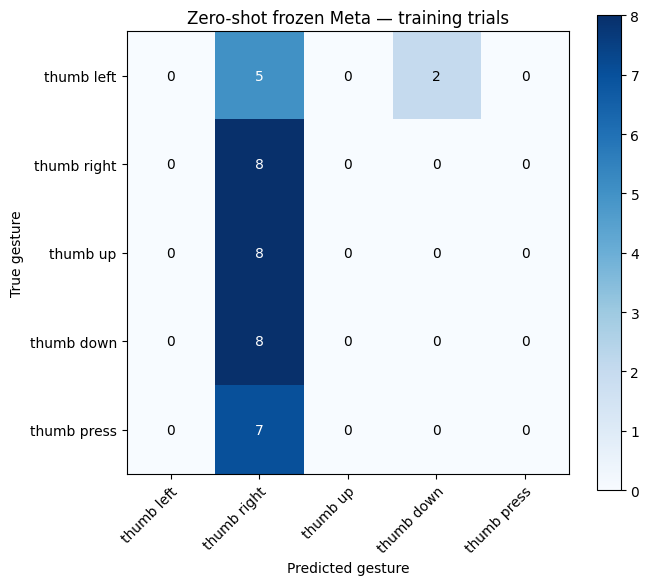


VALIDATION ZERO-SHOT RESULTS
Complete-trial accuracy: 1/5 = 0.2000
Active-bin task BCE: 2.219160

WRONG   | G0 trial  4 | true=thumb left   | pred=thumb right  | runner-up=thumb down   | margin=0.0481 | active bins=55
          scores: thumb left=0.000, thumb right=0.000, thumb up=0.000, thumb down=0.000, thumb press=0.000
CORRECT | G1 trial  4 | true=thumb right  | pred=thumb right  | runner-up=thumb press  | margin=0.3040 | active bins=85
          scores: thumb left=0.000, thumb right=0.000, thumb up=0.000, thumb down=0.000, thumb press=0.000
WRONG   | G2 trial  4 | true=thumb up     | pred=thumb right  | runner-up=thumb down   | margin=0.2509 | active bins=65
          scores: thumb left=0.000, thumb right=0.000, thumb up=0.000, thumb down=0.000, thumb press=0.000
WRONG   | G3 trial  4 | true=thumb down   | pred=thumb right  | runner-up=thumb down   | margin=0.3974 | active bins=75
          scores: thumb left=0.000, thumb right=0.000, thumb up=0.000, thumb down=0.000, thumb press

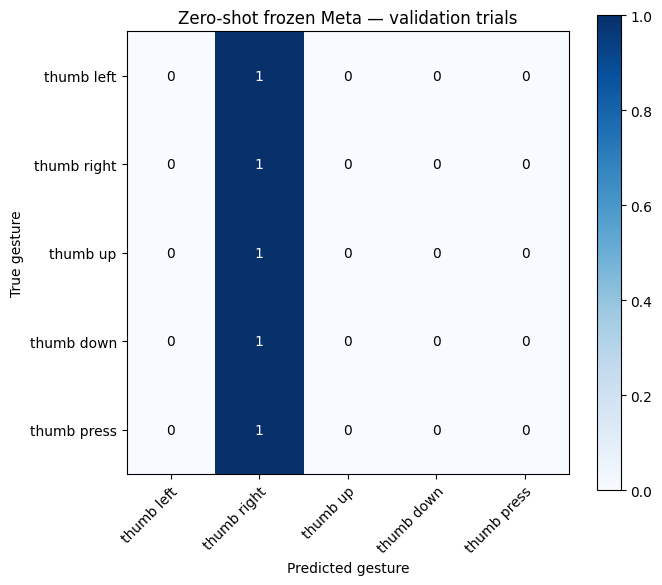


TEST ZERO-SHOT RESULTS
Complete-trial accuracy: 1/5 = 0.2000
Active-bin task BCE: 2.210873

WRONG   | G0 trial  5 | true=thumb left   | pred=thumb right  | runner-up=thumb down   | margin=0.4102 | active bins=51
          scores: thumb left=0.000, thumb right=0.000, thumb up=0.000, thumb down=0.000, thumb press=0.000
CORRECT | G1 trial  5 | true=thumb right  | pred=thumb right  | runner-up=thumb down   | margin=0.1322 | active bins=75
          scores: thumb left=0.000, thumb right=0.000, thumb up=0.000, thumb down=0.000, thumb press=0.000
WRONG   | G2 trial  5 | true=thumb up     | pred=thumb right  | runner-up=thumb down   | margin=0.3700 | active bins=65
          scores: thumb left=0.000, thumb right=0.000, thumb up=0.000, thumb down=0.000, thumb press=0.000
WRONG   | G3 trial  5 | true=thumb down   | pred=thumb right  | runner-up=thumb down   | margin=0.3301 | active bins=75
          scores: thumb left=0.000, thumb right=0.000, thumb up=0.000, thumb down=0.000, thumb press=0.000

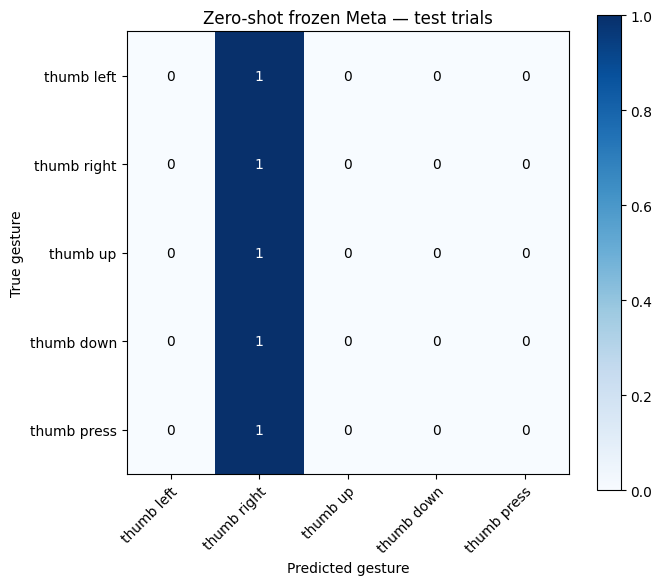


ZERO-SHOT SUMMARY
Train accuracy: 0.2105 (8/38)
Validation accuracy: 0.2000 (1/5)
Test accuracy: 0.2000 (1/5)
Test task BCE: 2.210873
Frozen Meta mutation check: PASSED

Use the TEST accuracy above as the strict zero-shot baseline for comparison with the learned-adapter model.


In [4]:
# ============================================================
# CELL 4 — RUN STRICT ZERO-SHOT EVALUATION
# No training, optimizer, adapter, CORAL, or checkpoint selection.
# ============================================================

print("=" * 100)
print("STRICT ZERO-SHOT FROZEN META EVALUATION")
print("=" * 100)
print(
    "Fixed bridge:",
    ZERO_SHOT_CHANNEL_BRIDGE,
)
print(
    "Learned parameters:",
    0,
)
print(
    "CORAL:",
    "OFF",
)
print(
    "Chance accuracy for five gestures:",
    "0.2000",
)


# ------------------------------------------------------------
# Preflight one batch
# ------------------------------------------------------------

preflight_batch = next(
    iter(train_loader)
)

preflight_emg = preflight_batch[0].to(
    DEVICE,
    dtype=torch.float32,
)

with torch.no_grad():
    preflight_meta_input = (
        fixed_adjacent_pair_mean(
            preflight_emg
        )
    )

    preflight_raw_output = meta_model(
        preflight_meta_input
    )

    preflight_mapped_output = (
        map_meta_outputs_to_utah(
            preflight_raw_output
        )
    )


print()
print("Preflight shapes:")
print(
    "  Utah after preprocessing:",
    tuple(preflight_emg.shape),
)
print(
    "  Fixed Meta input:",
    tuple(preflight_meta_input.shape),
)
print(
    "  Raw Meta output:",
    tuple(preflight_raw_output.shape),
)
print(
    "  Mapped Utah output:",
    tuple(preflight_mapped_output.shape),
)

if preflight_meta_input.shape[1:] != (
    META_CHANNELS,
    META_INPUT_SAMPLES,
):
    raise RuntimeError(
        "Fixed bridge produced an invalid Meta input."
    )

if not torch.isfinite(
    preflight_meta_input
).all():
    raise RuntimeError(
        "Fixed Meta input contains non-finite values."
    )

if not torch.isfinite(
    preflight_raw_output
).all():
    raise RuntimeError(
        "Meta output contains non-finite values."
    )


def print_signal_summary(
    name,
    tensor,
):
    value = (
        tensor.detach()
        .float()
        .cpu()
    )

    print(
        f"{name:<30} "
        f"mean={float(value.mean()):+.3e} | "
        f"std={float(value.std(unbiased=False)):.3e} | "
        f"rms="
        f"{float(torch.sqrt(value.square().mean())):.3e} | "
        f"range=[{float(value.min()):+.3e},"
        f"{float(value.max()):+.3e}]"
    )


print()
print("Preflight signal scale:")
print_signal_summary(
    "Utah 32-channel input",
    preflight_emg,
)
print_signal_summary(
    "Fixed 16-channel input",
    preflight_meta_input,
)
print_signal_summary(
    "Raw Meta output",
    preflight_raw_output,
)


# ------------------------------------------------------------
# Evaluate all fixed splits
# ------------------------------------------------------------

train_result = evaluate_zero_shot_loader(
    train_loader,
    "train",
)

val_result = evaluate_zero_shot_loader(
    val_loader,
    "validation",
)

test_result = evaluate_zero_shot_loader(
    test_loader,
    "test",
)


print_split_result(
    train_result
)
plot_confusion_matrix(
    train_result["confusion"],
    "Zero-shot frozen Meta — training trials",
)

print_split_result(
    val_result
)
plot_confusion_matrix(
    val_result["confusion"],
    "Zero-shot frozen Meta — validation trials",
)

print_split_result(
    test_result
)
plot_confusion_matrix(
    test_result["confusion"],
    "Zero-shot frozen Meta — test trials",
)


# ------------------------------------------------------------
# Frozen-model mutation check
# ------------------------------------------------------------

final_meta_signature = module_numeric_signature(
    meta_model
)

if final_meta_signature != initial_meta_signature:
    raise RuntimeError(
        "Frozen Meta parameters changed during evaluation."
    )


print()
print("=" * 100)
print("ZERO-SHOT SUMMARY")
print("=" * 100)
print(
    f"Train accuracy: "
    f"{train_result['accuracy']:.4f} "
    f"({train_result['correct']}/"
    f"{train_result['total']})"
)
print(
    f"Validation accuracy: "
    f"{val_result['accuracy']:.4f} "
    f"({val_result['correct']}/"
    f"{val_result['total']})"
)
print(
    f"Test accuracy: "
    f"{test_result['accuracy']:.4f} "
    f"({test_result['correct']}/"
    f"{test_result['total']})"
)
print(
    f"Test task BCE: "
    f"{test_result['task_bce']:.6f}"
)
print(
    "Frozen Meta mutation check: PASSED"
)

print()
print(
    "Use the TEST accuracy above as the strict zero-shot "
    "baseline for comparison with the learned-adapter model."
)
